In [1]:
#This notebook generates the Nguyen figures that comprise Figure 2 in the paper

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import pyrenn
sns.set(style='ticks')
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter
from scipy.interpolate import griddata
from scipy.stats import spearmanr
from matplotlib.pyplot import figure
from sklearn.metrics import mean_squared_error
from sklearn.metrics import root_mean_squared_error
from pickle import load
import matplotlib.gridspec as gridspec
import ast
import sys
BMS_path='../bin/'
sys.path.append(BMS_path + 'no_degeneracy/')
sys.path.append(BMS_path + 'no_degeneracy/Prior/')
from mcmc import *
from parallel import *
from fit_prior import read_prior_par
import math


#colors from seaborn's colorblind palette
#-----------------------------------------------
color_data=sns.color_palette("colorblind")[7]
color_noise=sns.color_palette("colorblind")[7]


colors={'4e-3x':['#fee0d2', '#deebf7'],
       '2x':['#fc9272', '#9ecae1'],
       '1x':['#de2d26', '#3182bd'] }

color_ann=colors['1x'][0]
color_bms=colors['1x'][1]
#-----------------------------------------------

In [25]:
#A function to return mdl models from traces
#------------------------------------------------------
def get_mdl(df_var, trace_var,two_dimensions=False ):

    
     #Two-dimensional (only nguyen n=10) or one-dimensional functions
    if two_dimensions==True:
         VARS = ['x','y',]
         prior_par = read_prior_par(BMS_path + 'no_degeneracy/Prior/final_prior_param_sq.named_equations.nv2.np10.2016-09-09 18:49:42.600380.dat')
    else:
        VARS = ['x',]
        prior_par = read_prior_par(BMS_path + 'no_degeneracy/Prior/final_prior_param_sq.named_equations.nv1.np10.2017-10-18 18:07:35.089658.dat')

    #Discriminate ann-generated vs nugyen functions
    #-----------------------------------------------
    try:
        x = df_var[[c for c in VARS]].copy()
        y=df_var.z_noise   
    except KeyError:
        VARS = ['x1',]
        x = df_var[[c for c in VARS]].copy()
        y=df_var.y_noise
    #-----------------------------------------------
    
    minrow = trace_var[trace_var.H == min(trace_var.H)].iloc[0]
    minH, minexpr, minparvals = minrow.H, minrow.expr, ast.literal_eval(minrow.parvals)
    
    tvar= Tree(
        variables=list(x.columns),
        parameters=['a%d' % i for i in range(NPAR)],
        x=x, y=y,
        prior_par=prior_par,
        max_size=200,
        from_string=minexpr,
    )

    tvar.set_par_values(deepcopy(minparvals))
    x_var=x;y_var=y
    
    return tvar, x_var, y_var
#------------------------------------------------------

#Figure settings
#--------------------------------

#Paths, extensions, and figure size
#--------------------------------
output_path='../results/paper_figures/figure2_nguyen/'      
extensions=['.svg', '.png']    
#Define figure size in cm
cm = 1/2.54 #convert inch to cm
width = 16*cm; height=16*cm 
#--------------------------------

#Text sizes  
#--------------------------------
size_axis=16;size_ticks=14;
size_title=16;
line_w=3;marker_s=8;m_size=10
size_legend=14
#--------------------------------

#ticks and limits for ng1 functions
#--------------------------------
#xtick_labels_ng1=[-1, 0, 1 ];ytick_labels_ng1=[ -3, 0, 3, 6.0]
#xmin_ng1=-1.1;xmax_ng1=1.1;ymin_ng1=-3.25;ymax_ng1=8
#--------------------------------

#ticks and limits for ng10 functions
#--------------------------------
#xtick_labels_ng10=[0, 0.5, 1 ];ytick_labels_ng10=[ 0, 0.5, 1.0];ztick_labels_ng10=[ 0, 0.5, 1.0]
#xmin_ng10=-0.1;xmax_ng10=1.1;ymin_ng10=-0.1;ymax_ng10=1.1;
#zmin_ng10=-0.1;zmax_ng10=1

ticks={1:{'x':[0, 0.5, 1],'y':[ -3, 0, 3, 6.0]}, 5:{'x':[-1, 0, 1], 'y':[-0.75,-0.5, -0.25]}, 
       7:{'x':[0,1,2,],   'y': [1,2,3]}, 8:{'x':[0,2,4], 'y':[0, 1, 2]}, 
       10:{'x':[0,0.5,1], 'y':[0,0.5,1], 'z':[0,0.5,1] } }

limits={1:{'x':[-1.1,1.1], 'y':[-3.25, 8]}, 5:{'x':[-1.2,1.2], 'y':[-0.8,-0.2]}, 
        7:{'x':[-0.1,2.1], 'y': [0.4,3.1]}, 8:{'x':[-0.1,4.2], 'y':[-0.1, 2.5]}, 
        10:{'x':[-0.1,1.1], 'y':[-0.1,1.1], 'z':[-0.1,1.1] } } 

coordinates_text={7:[0.4, 0.75], 8:[0.4, 0.3], 10:[0.15, 0.15, 0.3]}
#--------------------------------

#nguyen title dict
#--------------------------------
titles={1: r'$y_1=3.39 x^3 + 2.12 x^2 +1.78x$',
        5: r'$y_5=\sin(x^2) \cos(x)$', 
        7: r'$y_7=\log(x+1.4) + \log(x^2 + 1.3)$',
        8: r'$y_8=\sqrt{1.23x}$',
        10:r'$y_{10}=\sin(1.5x) \cos(0.5y)$' }
#--------------------------------


#Approximations, interpolations, extrapolations
#--------------------------------
#markers = {'rmse_nn': 'o', 'rmse_mdl': 's'};
markers = {'rmse_nn_train': 'o', 'rmse_mdl_train': 's'}
xtick_labels=np.arange(0.0,0.22,0.04)

resamples=100000; bs_seed=1111
ymin=1e-17;ymax=10
#--------------------------------

In [28]:
#Read Nguyen data

NPAR=10 #10, 20
steps=50000

path_nguyen_nn= '../data/nns/nguyen/approximation/'

#Read nguyen data
#-------------------------------------------------------------------------------
functions_to_plot={8: {'sigma': 0.0, 'realization': 1}, 
                   9: {'sigma': 0.02,'realization': 0}, 
                   10:{'sigma': 0.04,'realization': 2} }
    
#n=7;sigma=0.04;realization=0
#n=8;sigma=0.04;realization=0
#n=10;sigma=0.0;realization=0

n=10;sigma=0.02;realization=1

file_model_ng1= path_nguyen_nn + 'NN_no_overfit_sigma_' + str(sigma) + '_r_' + str(realization) + '.csv'
dng1=pd.read_csv(file_model_ng1,index_col=0)
#-------------------------------------------------------------------------------

#Read nguyen trace
#-------------------------------------------------------------------------------
dng1=dng1[dng1['rep']==n]
dng1=dng1.reset_index(drop=True)
path_nguyen_bms='../data/MSTraces/nguyen/'
trace_ng=path_nguyen_bms + 'BMS_nguyen_n_' + str(n)+'_sigma_'+str(sigma)+ '_r_' + str(realization) + '_id_0_trace_'+str(steps)+'_prior_10'+ '.csv'
trace=pd.read_csv(trace_ng, sep=';', header=None, names=['t', 'H', 'expr', 'parvals', 'kk1', 'kk2','kk3'])

if n!=10:
    t1,x1,y1=get_mdl(dng1, trace)
else:
    t1,x1,y1=get_mdl(dng1, trace, two_dimensions=True)
#-------------------------------------------------------------------------------


(y * (_a0_ * cos(y)))

{'d0': {'_a0_': 1.5017297571559103,
  '_a1_': 1.0,
  '_a2_': 1.0,
  '_a3_': 1.0,
  '_a4_': 1.0,
  '_a5_': 1.0,
  '_a6_': 1.0,
  '_a7_': 1.0}}

<Figure size 1889.76x1889.76 with 0 Axes>

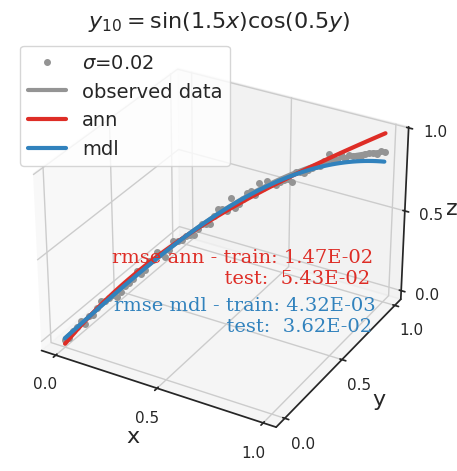

In [30]:
#Plot ann+bms predictions
dplot = deepcopy(dng1)
dplot['ybms'] = t1.predict(x1)

if dplot.ybms.isnull().values.any():
    print("there are Nans in the bms prediction")

#Validation and train borders
n_points=int(len(dng1.index))
train_fraction=5/8;valid_fraction=1/8;test_fraction=0.2
train_size_ann=int(n_points*train_fraction)
train_size_bms=train_size_ann + int(n_points*valid_fraction)
train_border=dng1.loc[train_size_bms-1]['x']

#Compute rmse errors
rmse_nn_train=root_mean_squared_error(dplot.loc[:train_size_bms-1]['zmodel'],dplot.loc[:train_size_bms -1]['z'])
rmse_nn_test=root_mean_squared_error(dplot.loc[train_size_bms-1:]['zmodel'],dplot.loc[train_size_bms -1:]['z'])

try:
    rmse_mdl_train=root_mean_squared_error(dplot.loc[:train_size_bms-1]['ybms'],dplot.loc[:train_size_bms-1]['z'])
except ValueError:
    rmse_mdl_train=np.inf
try:
    rmse_mdl_test =root_mean_squared_error(dplot.loc[train_size_bms-1:]['ybms'],dplot.loc[train_size_bms-1:]['z'])
except ValueError:
    rmse_mdl_test=np.inf


#Plot figure
fig=figure(figsize=(width,height), dpi=300)  

if n==10:
    ax = plt.figure().add_subplot(projection='3d')

    ax.plot(dng1.x, dng1.y, dng1.z_noise, '.', markersize=marker_s, linewidth=line_w,color=color_noise, label=r'$\sigma$='+str(sigma))
    ax.plot(dng1.x, dng1.y, dng1.z, linewidth=line_w, color=color_data,label='observed data')
    ax.plot(dng1['x'], dng1['y'], dng1['zmodel'],linewidth=line_w, color=color_ann, label='ann')
    ax.plot(dplot.x, dplot.y, dplot.ybms, linewidth=line_w,color=color_bms,label='mdl')
    
    ax.set_xticks(ticks[n]['x']);ax.set_yticks(ticks[n]['y']);ax.set_zticks(ticks[n]['z'])
    ax.set_xlabel('x',fontsize=size_axis);ax.set_ylabel('y',fontsize=size_axis);ax.set_zlabel('z',fontsize=size_axis)
    ax.zaxis.labelpad=0.0 #This ensures the z label will show up

    ax.text(coordinates_text[n][0], coordinates_text[n][1],coordinates_text[n][2],\
            'rmse ann - train: %.2E \n                  test:  %.2E' %( rmse_nn_train, rmse_nn_test),\
            color=color_ann,fontsize=size_legend,fontname='serif')
    ax.text(coordinates_text[n][0], coordinates_text[n][1],coordinates_text[n][2] -0.3,\
            'rmse mdl - train: %.2E \n                  test:  %.2E' %(rmse_mdl_train, rmse_mdl_test),\
            color=color_bms,fontsize=size_legend,fontname='serif')
else:
    plt.plot(dng1['x'], dng1['z_noise'],'.', markersize=marker_s, color=color_noise,label=r'$\sigma$='+str(sigma)) 
    plt.plot(dng1['x'], dng1['z'], linewidth=line_w, color=color_data,label='observed data') 
    plt.plot(dng1['x'], dng1['zmodel'],linewidth=line_w, color=color_ann, label='ann')
    plt.plot(dplot.x, dplot.ybms, linewidth=line_w,color=color_bms,label='mdl' )
    
    
    train_border=dng1.loc[train_size_bms-1]['x']
    plt.axvline(x=train_border,linestyle='--',linewidth=line_w, color='k')
    plt.xlabel('x',fontsize=size_axis);plt.ylabel('y',fontsize=size_axis)
    plt.xticks(ticks[n]['x'], fontsize=size_ticks);plt.yticks(ticks[n]['y'], fontsize=size_ticks)
    plt.xlim(limits[n]['x'][0], limits[n]['x'][1]);plt.ylim(limits[n]['y'][0], limits[n]['y'][1])

    #Plot errors on figure
    plt.text(coordinates_text[n][0], coordinates_text[n][1], \
             'rmse ann - train: %.2E \n                  test:  %.2E' % ( rmse_nn_train,rmse_nn_test), \
             color=color_ann,fontsize=size_legend,fontname='serif')
    plt.text(coordinates_text[n][0], coordinates_text[n][1]-0.3, \
             'rmse mdl - train: %.2E \n                  test:  %.2E' % (rmse_mdl_train,rmse_mdl_test), \
             color=color_bms,fontsize=size_legend,fontname='serif')


plt.legend(loc='best', fontsize=size_legend)
plt.title(titles[n], fontsize=size_title)

#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
#plt.title('$y_{r%s}=%s$' %  (realization, t1.latex()), fontsize=size_title)
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

#set limits and layout
sns.despine();plt.tight_layout()

#Save figure
namefig=str(n)+'_nguyen_noise_predictions' + '_sigma_' + str(sigma) + '_r_'  + str(realization) + '_par_' + str(NPAR)

plt.savefig(output_path + namefig +'.svg',dpi=300)

display(t1,t1.par_values)

In [ ]:
# Approximations
#--------------------------------------------------------------------------------------------------------------
errors_approximation=pd.read_csv('../data/'+ 'all_errors_nguyen' + '.csv',index_col=0)
#only take rmse results
columns=["sigma", "function","rmse_nn_train", "rmse_nn_test", "rmse_mdl_train", "rmse_mdl_test","r"]
errors_approximation=errors_approximation[columns]
#Melt dataframes and divide train and test
errors_train=errors_approximation[["sigma", "function","rmse_nn_train", "rmse_mdl_train","r"]]
errors_train=errors_train.rename(columns={"rmse_nn_train": "rmse ann", "rmse_mdl_train": "rmse mdl"})#change name columns for legends
errors_train=pd.melt(errors_train,id_vars=["sigma","function","r"], var_name="error approx",value_name= "value approx")

display(errors_train)

#Errors test. Not used, in principle
errors_test=errors_approximation[["sigma", "function","rmse_nn_test", "rmse_mdl_test","r"]]
errors_test=pd.melt(errors_test,id_vars=["sigma","function", "r"], var_name="error_test", value_name= "value_test")
#--------------------------------------------------------------------------------------------------------------

#Inter-extrapolation errors
#--------------------------------------------------------------------------------------------------------------
errors_inter_extra=pd.read_csv('../data/'+ 'all_errors_nguyen_interpolation' + '.csv',index_col=0)
#only take rmse results
columns=["sigma", "function","rmse_nn_interp.", "rmse_nn_extrap.", "rmse_mdl_interp.", "rmse_mdl_extrap.","r"]

#interpolation
errors_inter=errors_inter_extra[["sigma", "function","rmse_nn_interp.", "rmse_mdl_interp.","r"]]
errors_inter=errors_inter.rename(columns={"rmse_nn_interp.": "rmse ann", "rmse_mdl_interp.": "rmse mdl"})#change column names for legends
errors_inter=pd.melt(errors_inter,id_vars=["sigma","function","r"], var_name="error interp",value_name= "value interp")
#errors_inter=pd.melt(errors_inter,id_vars=["sigma","function","r"], var_name="error",value_name= "value")

#extrapolation
errors_extra=errors_inter_extra[["sigma", "function","rmse_nn_extrap.", "rmse_mdl_extrap.","r"]]
errors_extra=errors_extra.rename(columns={"rmse_nn_extrap.": "rmse ann", "rmse_mdl_extrap.": "rmse mdl"})#change column names for legends
errors_extra=pd.melt(errors_extra,id_vars=["sigma","function", "r"], var_name="error extrap", value_name= "value extrap")
#--------------------------------------------------------------------------------------------------------------
display(errors_extra)

In [39]:
#Select function to plot
errors_train_plot=errors_train[errors_train['function']==n]
errors_inter_plot=errors_inter[errors_inter['function']==n]
errors_extra_plot=errors_extra[errors_extra['function']==n]

6.299212598425196 6.299212598425196


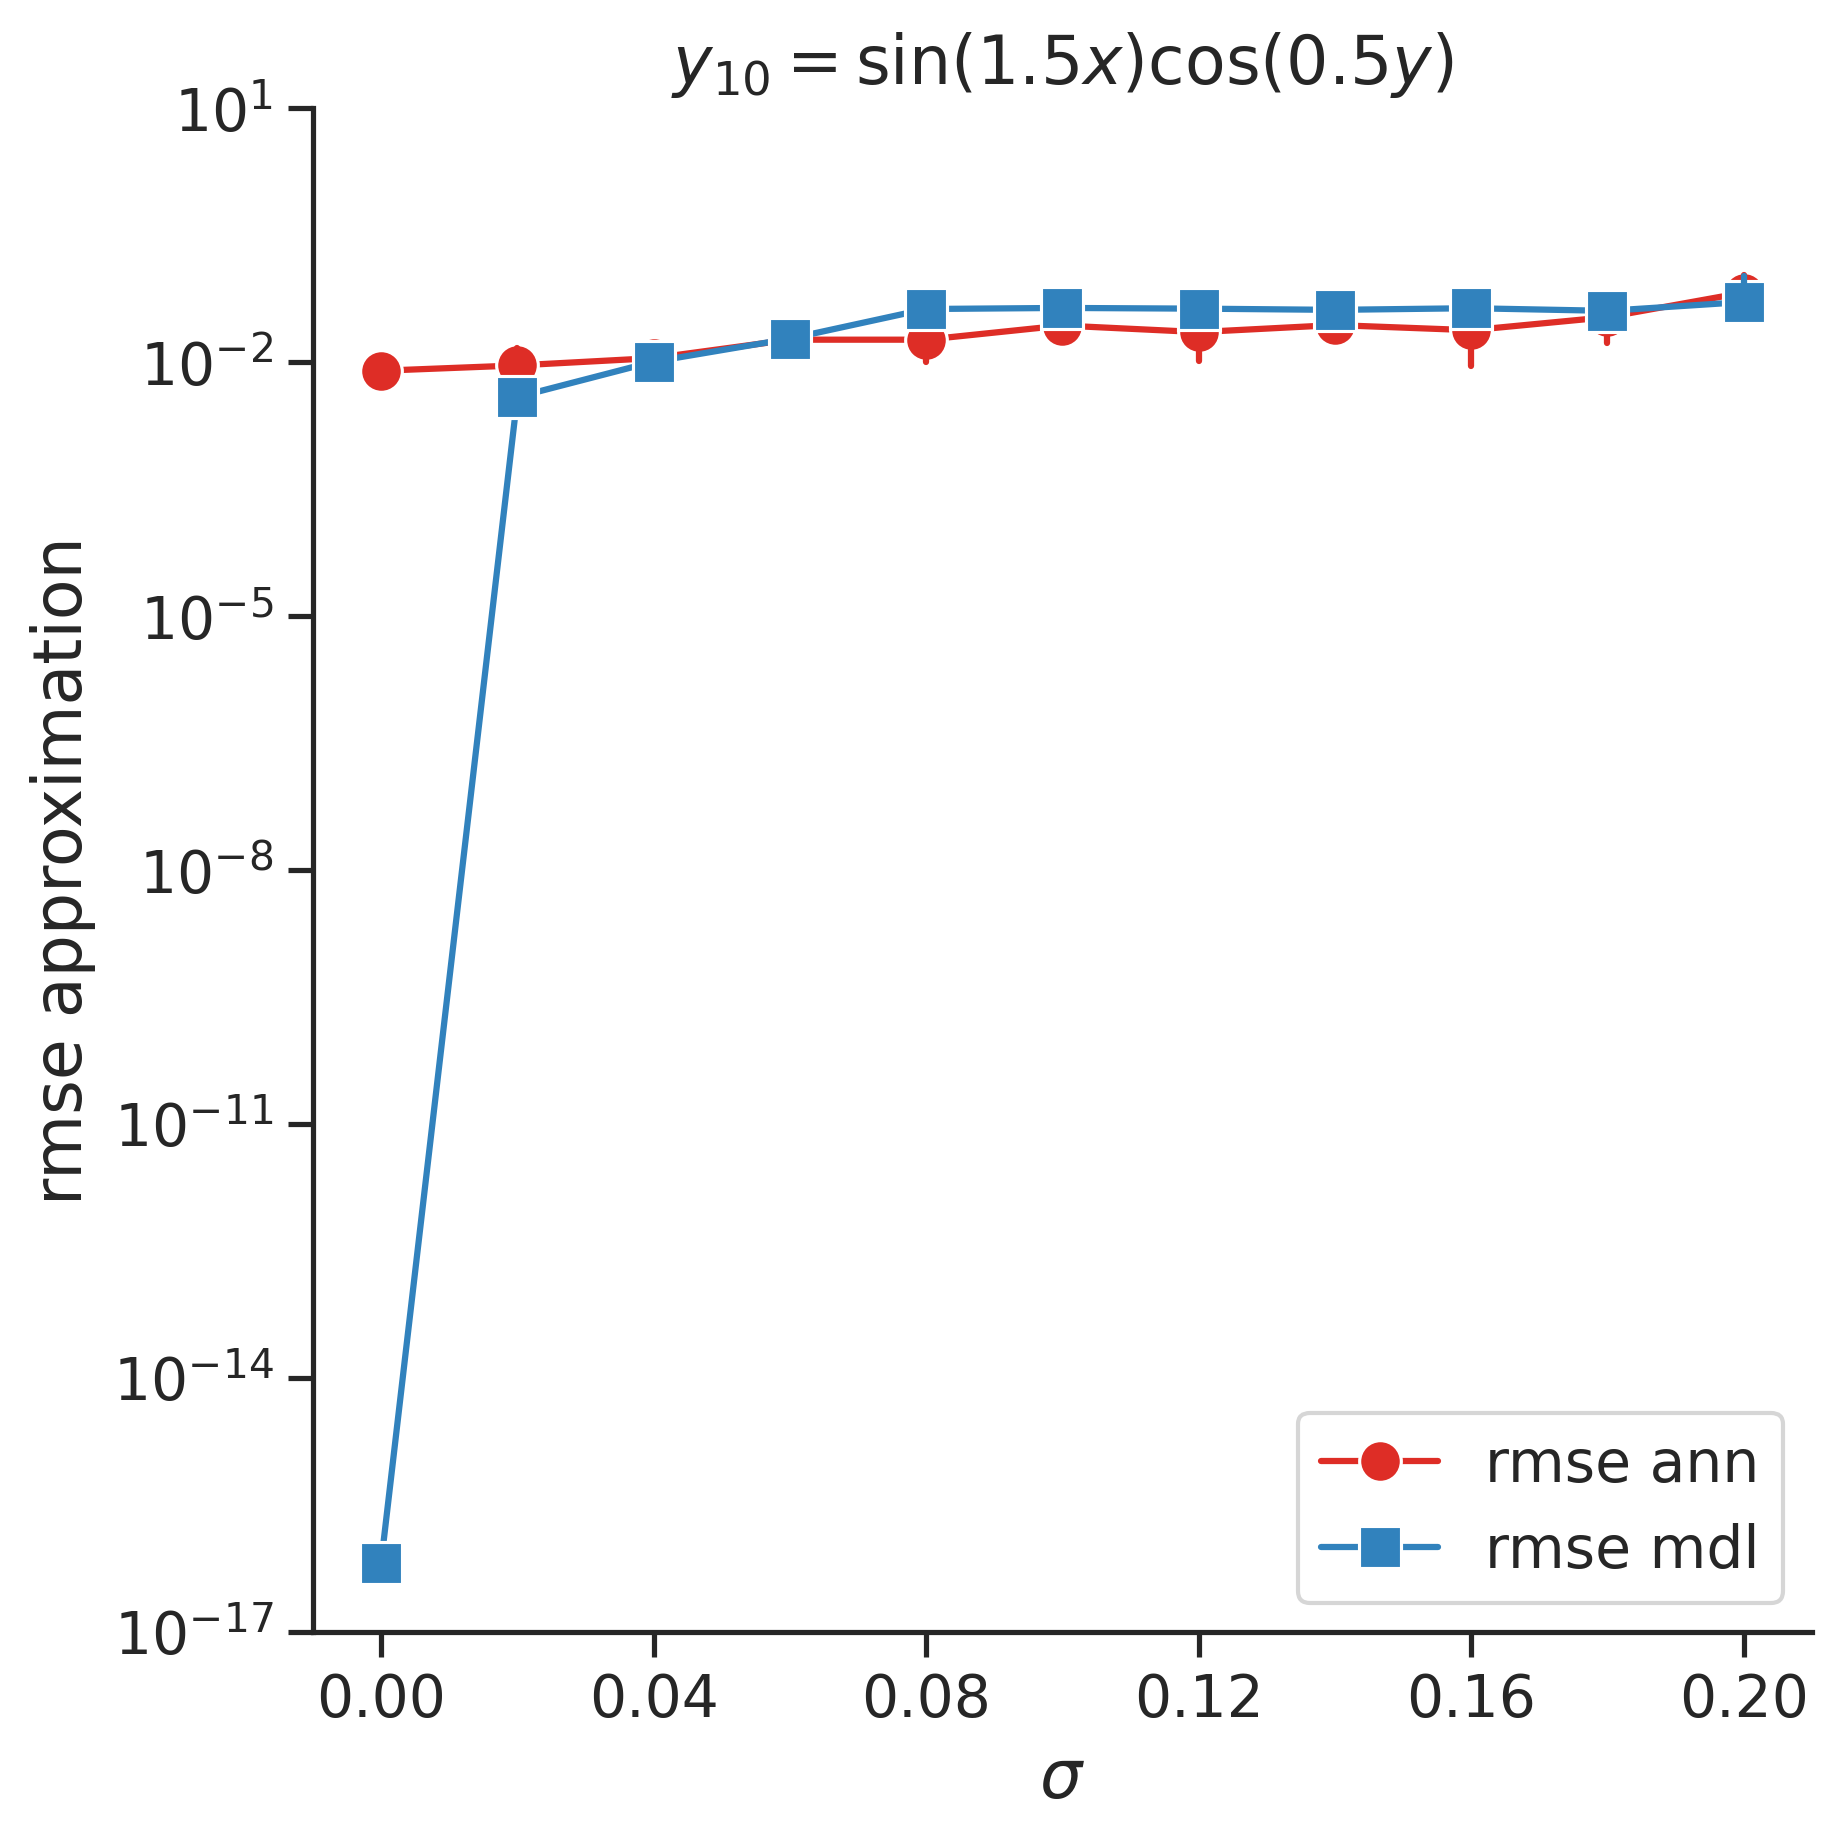

In [18]:
#approximation
#-------------------------------------------------------------------------------------------------------------------
fig=figure(figsize=(width,height), dpi=300)
print(width, height)

sns.lineplot(
        data=errors_train_plot, x='sigma', y='value approx', hue='error approx', style='error approx',
        estimator='median', err_style="bars", errorbar=('ci', 95), n_boot=resamples, seed=bs_seed,
        markers=[markers['rmse_nn_train'], markers['rmse_mdl_train']], dashes=False, markersize=m_size, legend="full", 
        palette=[colors['1x'][0], colors['1x'][1]])

#labels, limits, and ticks
plt.title(titles[n],fontsize=size_title)
plt.xlabel(r'$\sigma$',fontsize=size_axis);plt.ylabel('rmse approximation',fontsize=size_axis)
plt.yscale("log")
plt.xticks(fontsize=size_ticks);plt.yticks(fontsize=size_ticks)
xtick_labels=np.arange(0.0,0.22,0.04)
plt.xticks(xtick_labels, fontsize=size_ticks);plt.yticks(fontsize=size_ticks)
plt.minorticks_off()

plt.ylim(ymin,ymax);sns.despine();plt.tight_layout()

plt.legend(loc='lower right', fontsize=size_legend)

namefig_app='approximation_' + str(n) 
plt.savefig(output_path+namefig_app + '.svg',dpi=300)
#-------------------------------------------------------------------------------------------------------------------

6.299212598425196 6.299212598425196


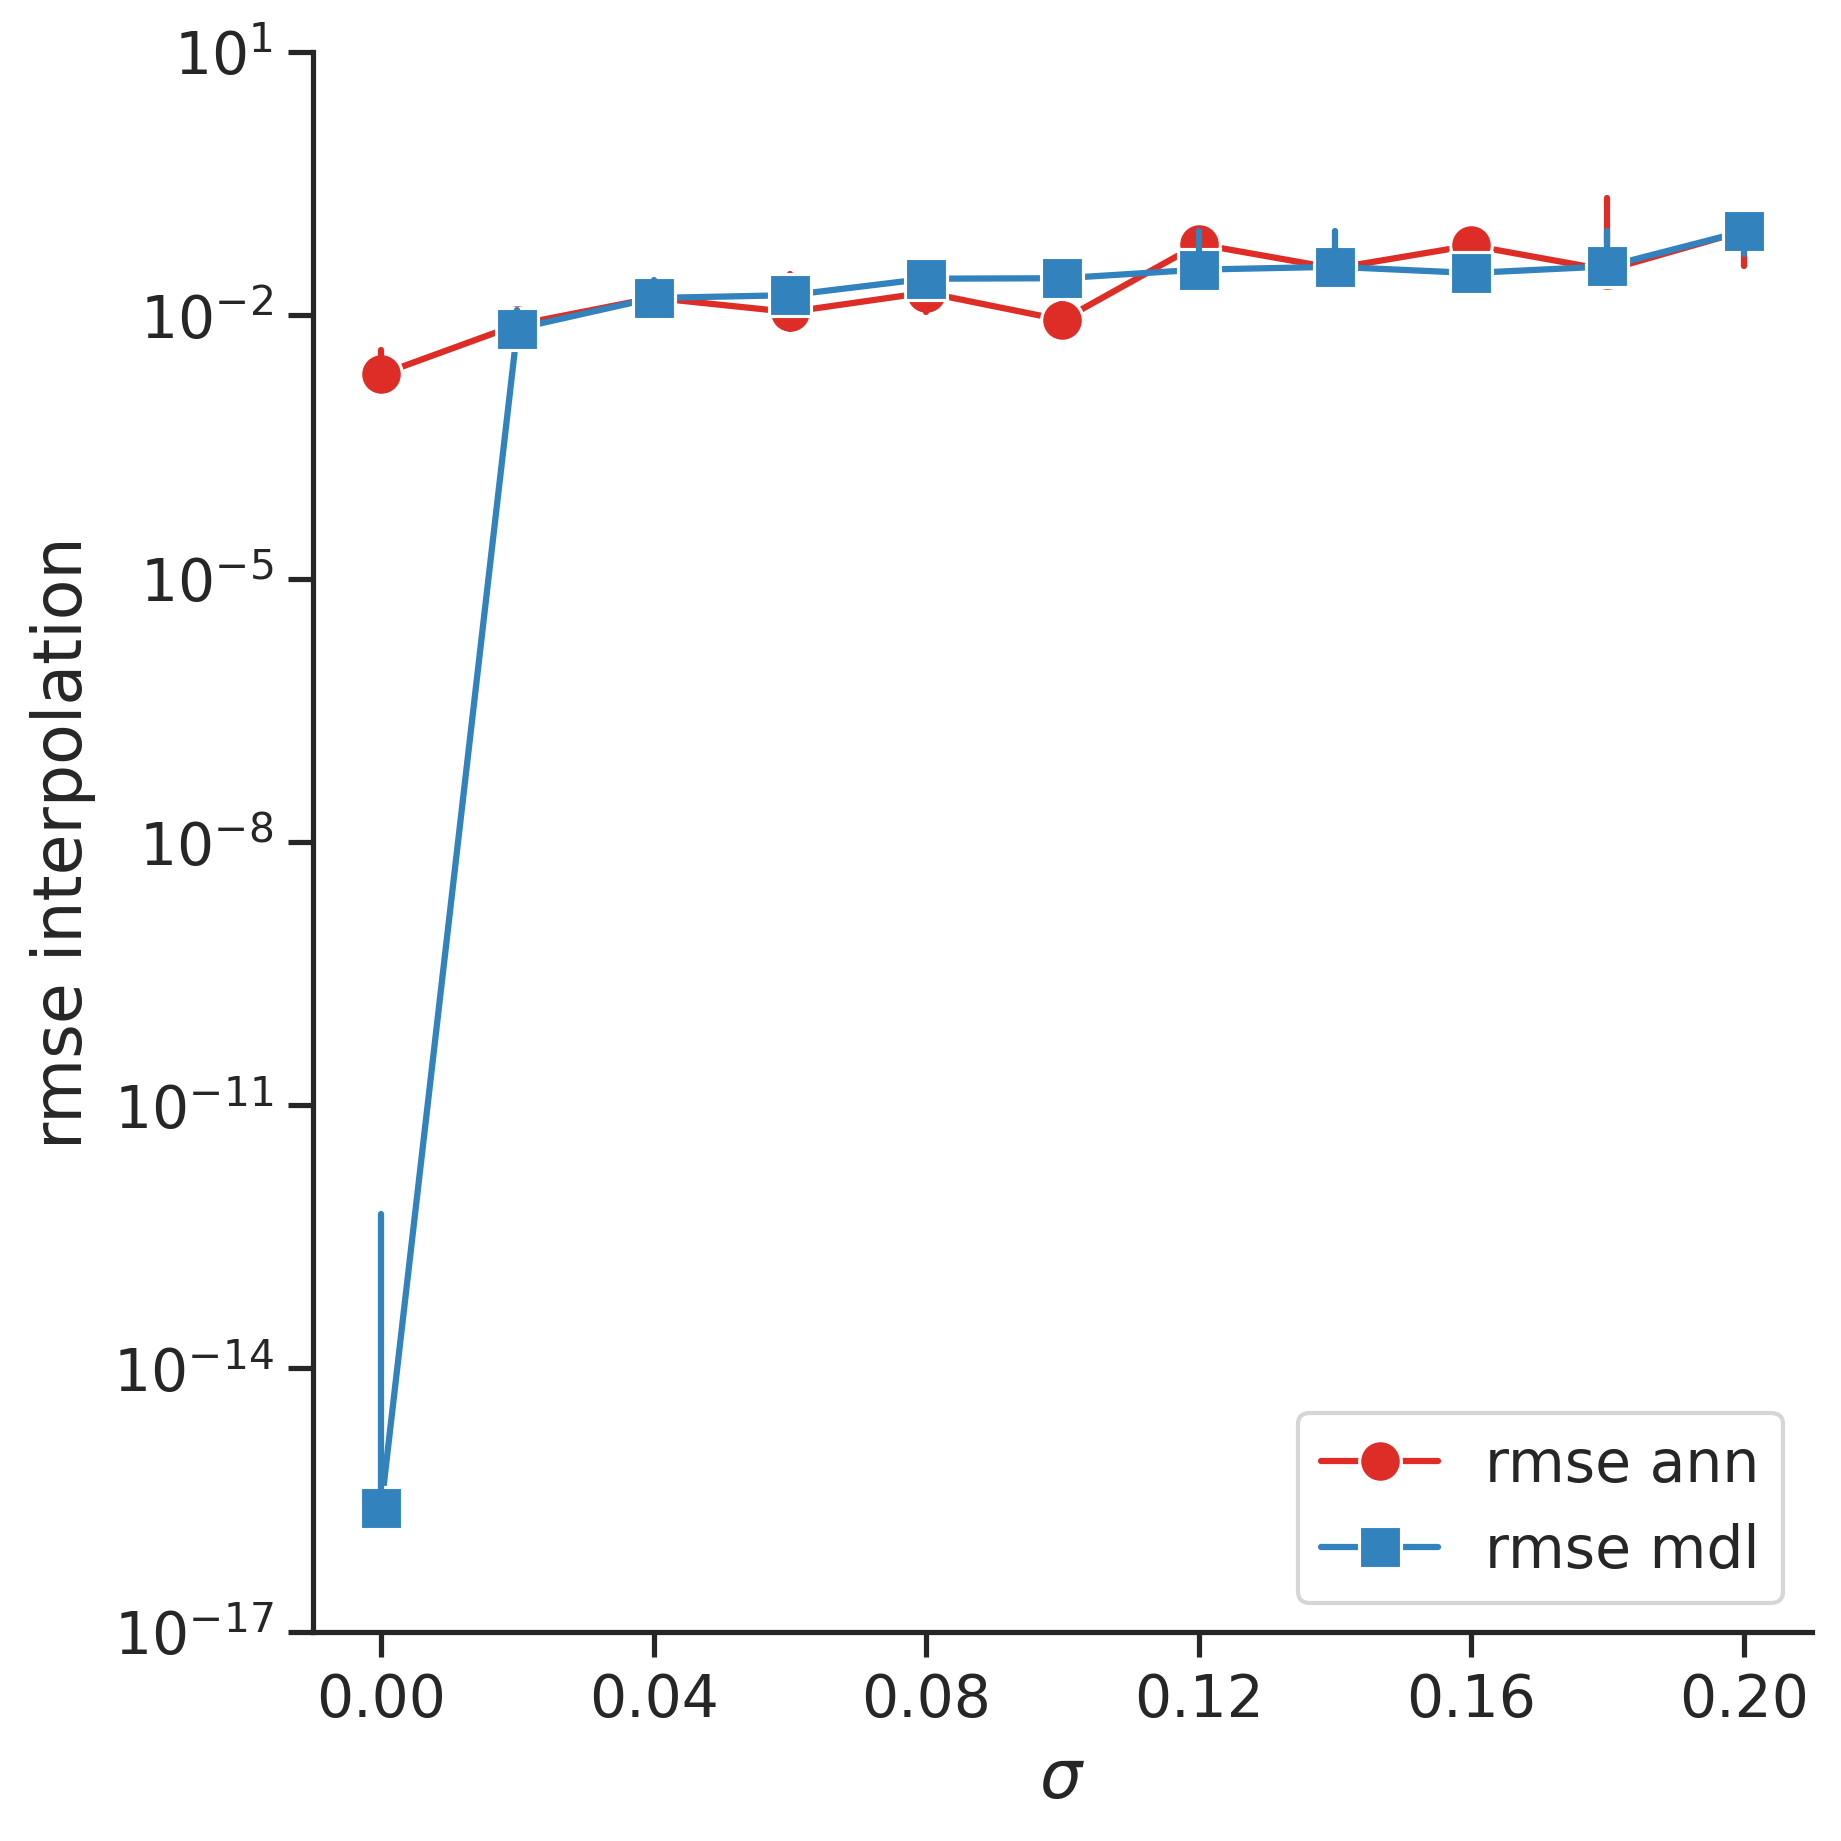

In [41]:
#interpolation
#-------------------------------------------------------------------------------------------------------------------
fig=figure(figsize=(width,height), dpi=300)
print(width, height)

#display(errors_inter_plot)

sns.lineplot(
        data=errors_inter_plot, x='sigma', y='value interp', hue='error interp', style='error interp',
        estimator='median', err_style="bars", errorbar=('ci', 95), n_boot=resamples, seed=bs_seed,
        markers=[markers['rmse_nn_train'], markers['rmse_mdl_train']], dashes=False, markersize=m_size, legend=True, 
        palette=[colors['1x'][0], colors['1x'][1]])

#labels, limits, and ticks
#plt.title(titles[func_number],fontsize=size_ticks)
plt.xlabel(r'$\sigma$',fontsize=size_axis);plt.ylabel('rmse interpolation',fontsize=size_axis)
plt.yscale("log")
plt.xticks(fontsize=size_ticks);plt.yticks(fontsize=size_ticks)
xtick_labels=np.arange(0.0,0.22,0.04)
plt.xticks(xtick_labels, fontsize=size_ticks);plt.yticks(fontsize=size_ticks)
plt.minorticks_off()
plt.ylim(ymin,ymax)

sns.despine();plt.tight_layout()

plt.legend(loc='lower right', fontsize=size_legend)

namefig_inter='interpolation_' + str(n)
plt.savefig(output_path+namefig_inter + '.svg',dpi=300)
#-------------------------------------------------------------------------------------------------------------------

6.299212598425196 6.299212598425196


,sigma,function,r,error extrap,value extrap
132,0.00,10,0,rmse ann,0.086537
133,0.00,10,1,rmse ann,0.089484
134,0.00,10,2,rmse ann,0.085267
135,0.02,10,0,rmse ann,0.084173
136,0.02,10,1,rmse ann,0.057564
...,...,...,...,...,...
325,0.18,10,1,rmse mdl,0.059974
326,0.18,10,2,rmse mdl,0.058731
327,0.20,10,0,rmse mdl,0.137436
328,0.20,10,1,rmse mdl,0.070091


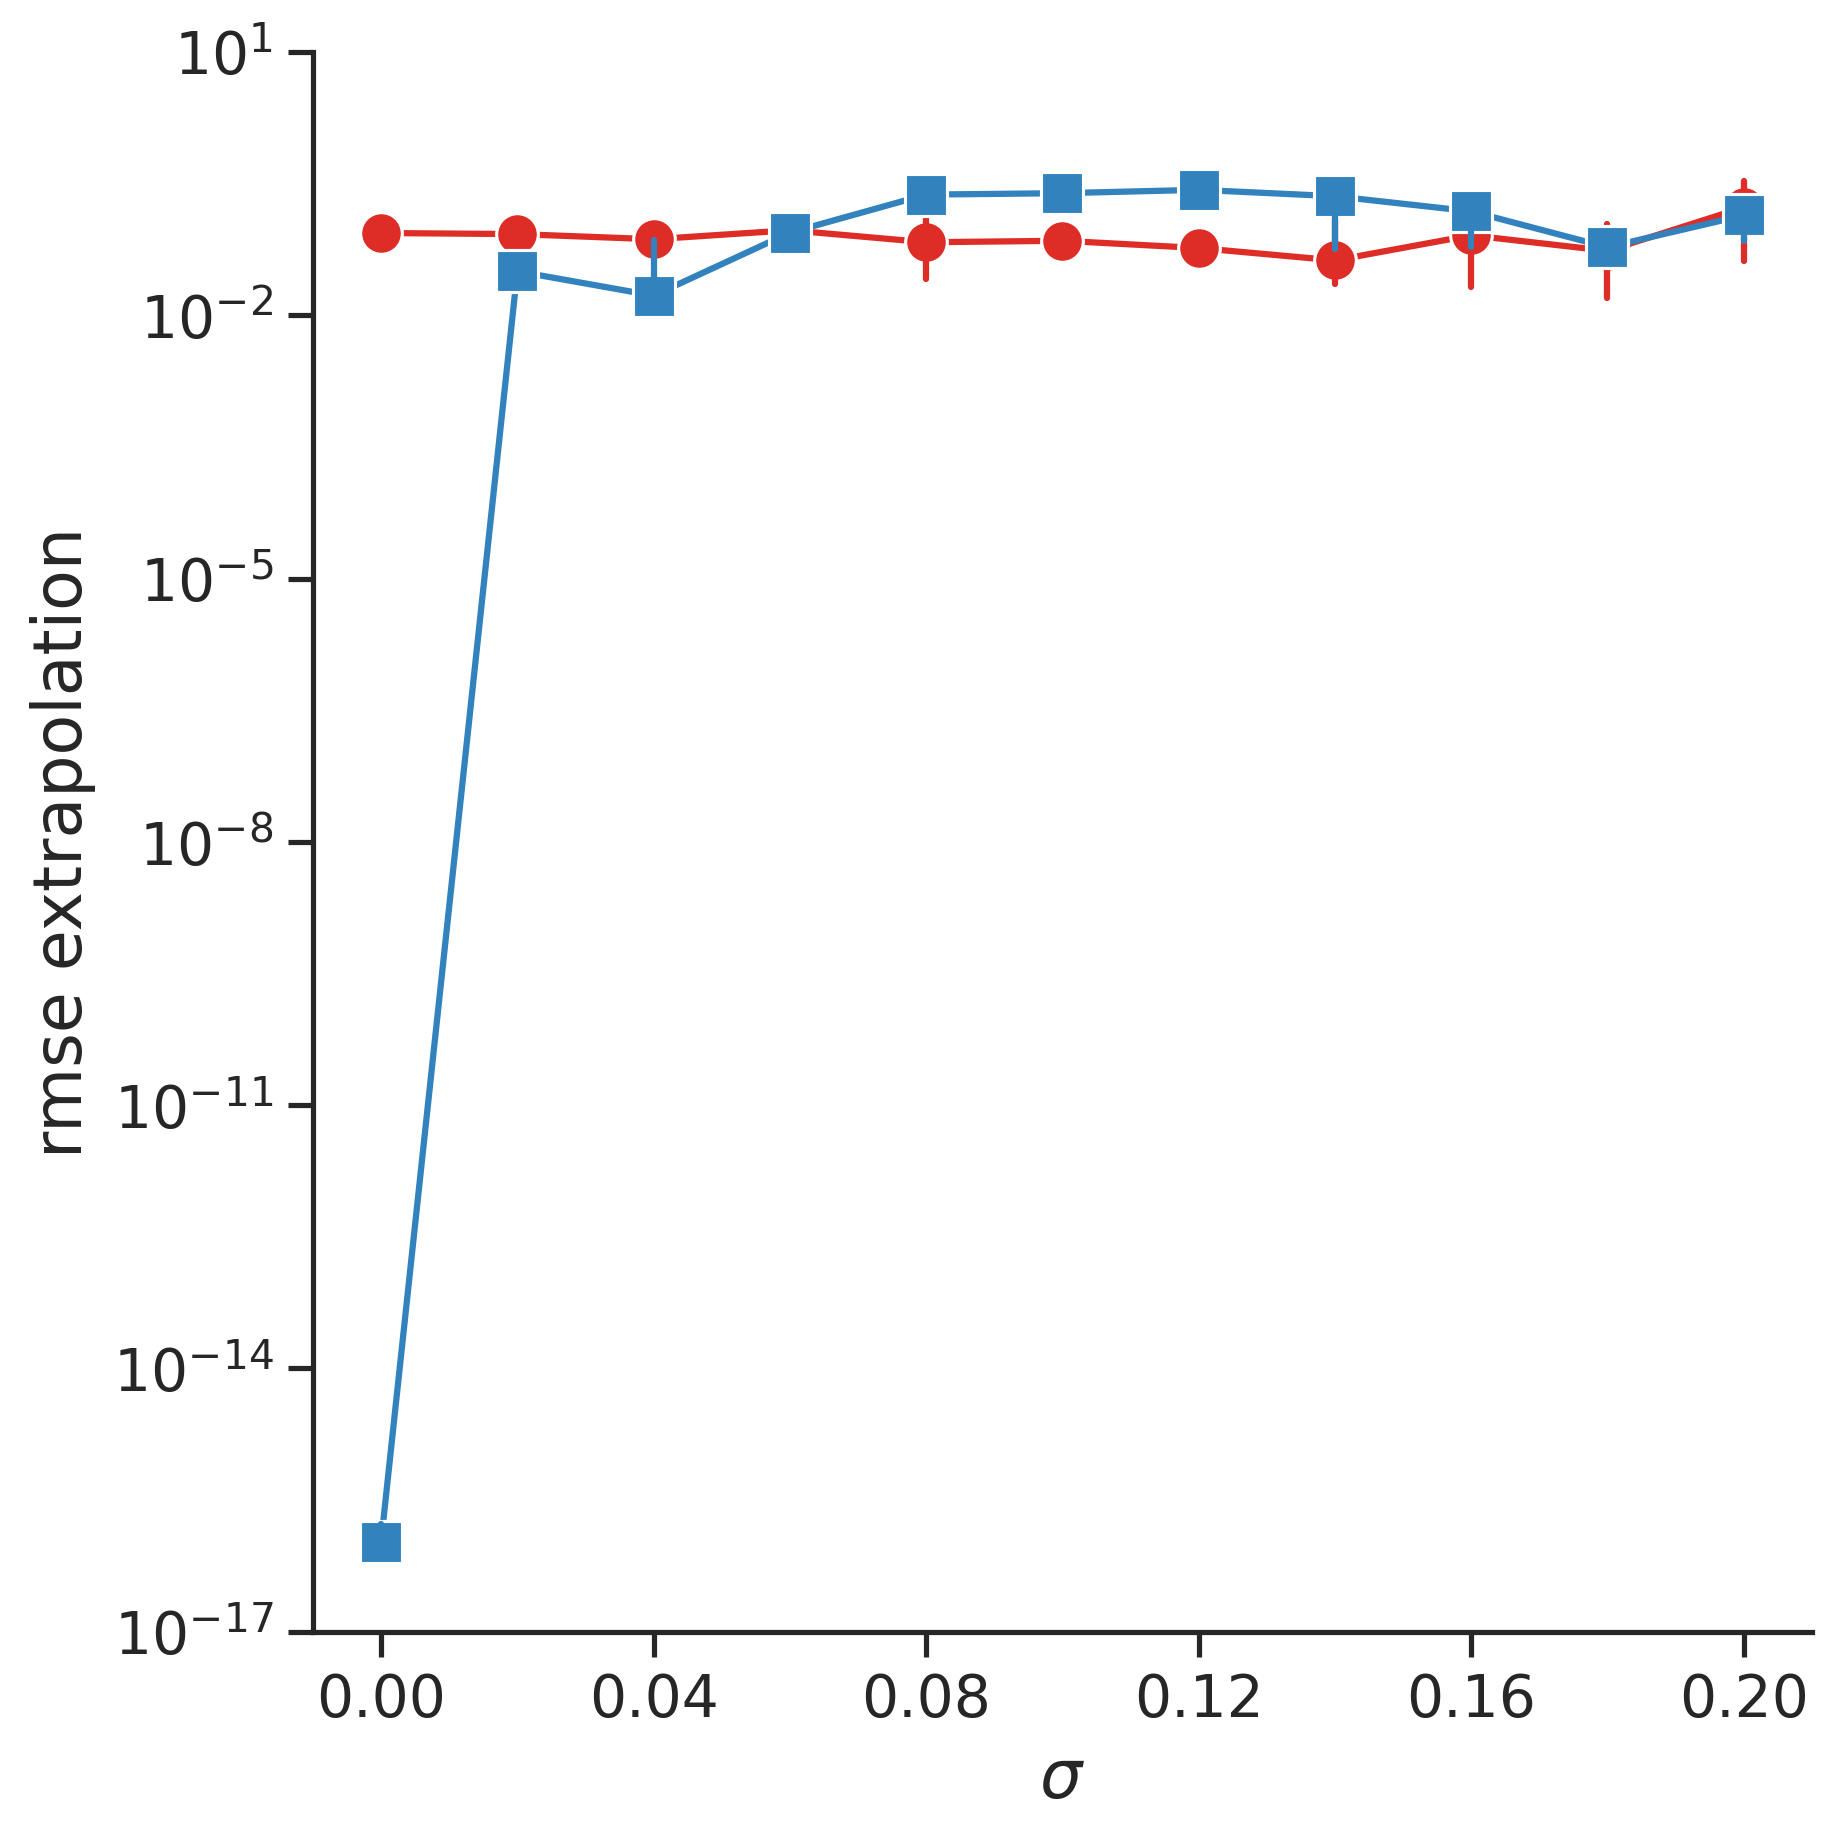

In [36]:
#Extrapolation
#-------------------------------------------------------------------------------------------------------------------
fig=figure(figsize=(width,height), dpi=300)
print(width, height)

display(errors_extra_plot)

sns.lineplot(
        data=errors_extra_plot, x='sigma', y='value extrap', hue='error extrap', style='error extrap',
        estimator='median', err_style="bars", errorbar=('ci', 95), n_boot=resamples, seed=bs_seed,
        markers=[markers['rmse_nn_train'], markers['rmse_mdl_train']], dashes=False, markersize=m_size, legend=False, 
        palette=[colors['1x'][0], colors['1x'][1]])

#labels, limits, and ticks
#plt.title(titles[func_number],fontsize=size_ticks)
plt.xlabel(r'$\sigma$',fontsize=size_axis);plt.ylabel('rmse extrapolation',fontsize=size_axis)
plt.yscale("log")
plt.xticks(fontsize=size_ticks);plt.yticks(fontsize=size_ticks)
xtick_labels=np.arange(0.0,0.22,0.04)
plt.xticks(xtick_labels, fontsize=size_ticks);plt.yticks(fontsize=size_ticks)
plt.minorticks_off()
plt.ylim(ymin,ymax)

sns.despine();plt.tight_layout()

namefig_extrap='extrapolation_' + str(n)
plt.savefig(output_path+namefig_extrap+ '.svg',dpi=300)
#-------------------------------------------------------------------------------------------------------------------